In [1]:
# Cell 1 : Imports & Device Check
import os, copy, warnings, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
%matplotlib inline

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True

print(f'PyTorch     : {torch.__version__}')
print(f'Torchvision : {torchvision.__version__}')
print(f'Device      : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM        : {total_mem:.1f} GB')


PyTorch     : 2.5.1+cu121
Torchvision : 0.20.1+cu121
Device      : cuda
GPU         : NVIDIA RTX 5000 Ada Generation
VRAM        : 32.0 GB


In [2]:
# Cell 2 : Config, Transforms & Data Loading
# ── Hyper-parameters ──────────────────────────────────────────────────────────
BATCH_SIZE  = 64
IMAGE_SIZE  = (224, 224)
EPOCHS      = 50
NUM_CLASSES = 6
RANDOM_SEED = 42

TRAIN_DIR  = r'..\Proposed_Dataset\train'
VAL_DIR    = r'..\Proposed_Dataset\validation'

for d in [TRAIN_DIR, VAL_DIR]:
    if not os.path.exists(d): raise FileNotFoundError(f'Not found: {d}')

os.makedirs('Model',   exist_ok=True)
os.makedirs('History', exist_ok=True)
os.makedirs('Images',  exist_ok=True)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Output directory : {os.path.abspath("Model")}')

# ── Transforms ────────────────────────────────────────────────────────────────
# Keras: Rescaling(1./127.5, offset=-1)
# PyTorch equivalent: ToTensor() maps [0,255]->[0,1],
#                     Normalize([0.5]*3,[0.5]*3) maps [0,1]->[-1,1]
MINUSONE_NORM = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(25),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), shear=5.7),
    transforms.ToTensor(),
    MINUSONE_NORM,
])
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    MINUSONE_NORM,
])

# ── Data Loading ──────────────────────────────────────────────────────────────
# TRAIN_DIR  -> training set (used as-is)
# VAL_DIR    -> split 50/50 stratified into val and test
N_WORKERS = 0
PIN       = (DEVICE.type == 'cuda')

train_dataset    = torchvision.datasets.ImageFolder(TRAIN_DIR, transform=TRAIN_TRANSFORM)
full_val_dataset = torchvision.datasets.ImageFolder(VAL_DIR,   transform=VAL_TRANSFORM)

all_indices = list(range(len(full_val_dataset)))
val_indices, test_indices = train_test_split(
    all_indices, test_size=0.5, random_state=RANDOM_SEED,
    stratify=full_val_dataset.targets
)

val_dataset  = Subset(full_val_dataset, val_indices)
test_dataset = Subset(full_val_dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=N_WORKERS, pin_memory=PIN)
val_loader   = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=PIN)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=PIN)

class_names  = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

assert train_dataset.classes == full_val_dataset.classes, \
    'Class mismatch between train and val directories!'

print(f'Train : {len(train_dataset)}  |  Val : {len(val_dataset)}  |  Test : {len(test_dataset)}')
print(f'Classes : {class_names}')
print(f'Batches -- Train : {len(train_loader)}  Val : {len(val_loader)}  Test : {len(test_loader)}')

# ── Class weights (computed from training set only) ───────────────────────────
class_weights_arr    = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES),
                                             y=train_dataset.targets)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32).to(DEVICE)
print(f'Class weights : {class_weights_arr}')


Output directory : c:\Users\km1612\Documents\riceMobileNet\RiceMobileNet_final\RiceMobileNEt Code\Experiment_on_proposed_DATASET\Proposed_model\Model
Train : 5603  |  Val : 744  |  Test : 745
Classes : ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']
Batches -- Train : 88  Val : 12  Test : 12
Class weights : [1.02281855 0.81344367 0.96073388 0.9191273  1.0672381  1.37530682]


In [4]:
# Cell 3 : Shared Utilities
# ── Freeze helper ─────────────────────────────────────────────────────────────
# The closest possible PyTorch equivalent of Keras:
#   model.trainable = True
#   for layer in model.layers[:-35]:
#       layer.trainable = False
#
# Keras counts every single operation (Conv2D, BN, Activation, Add ...) as 1 layer.
# PyTorch groups operations into hierarchical modules.
# The closest translation: collect all LEAF modules of the backbone
# (leaf = no child modules, e.g. Conv2d, BatchNorm2d, ReLU, MaxPool2d),
# which mirrors how Keras exposes individual layers,
# then freeze all except the last `n_trainable` of them.
def apply_freeze_like_keras(backbone, n_trainable=35, label='backbone'):
    # Step 1: make everything trainable  (model.trainable = True)
    for p in backbone.parameters():
        p.requires_grad = True

    # Step 2: collect all leaf modules in forward order
    leaf_modules = [
        (name, m) for name, m in backbone.named_modules()
        if len(list(m.children())) == 0        # leaf = no sub-modules
    ]

    # Step 3: freeze all except the last n_trainable leaves
    #         (for layer in model.layers[:-35]: layer.trainable = False)
    n_total  = len(leaf_modules)
    n_freeze = max(0, n_total - n_trainable)

    for name, mod in leaf_modules[:n_freeze]:
        for p in mod.parameters(recurse=False):
            p.requires_grad = False

    n_trainable_actual = n_total - n_freeze
    print(f'  {label}')
    print(f'    Total leaf modules  : {n_total}')
    print(f'    Frozen              : {n_freeze}')
    print(f'    Trainable (last {n_trainable})  : {n_trainable_actual}')
    return n_trainable_actual

# ── Early Stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience     = patience
        self.best_loss    = float('inf')
        self.counter      = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss    = val_loss
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)

# ── Training engine (Keras-style output) ──────────────────────────────────────
def run_training(model_name, model, train_loader, val_loader,
                 epochs=EPOCHS, device=DEVICE):
    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor, label_smoothing=0.1
    )
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5, verbose=True
    )
    scaler     = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
    early_stop = EarlyStopping(patience=10)

    n_steps = len(train_loader)
    history = {k: [] for k in [
        'loss', 'accuracy', 'precision', 'recall', 'f1_score',
        'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_f1_score'
    ]}

    print(f"\n{'='*72}")
    print(f'  Training : {model_name}')
    print(f'  Batch    : {BATCH_SIZE}  |  Device : {device}')
    if device.type == 'cuda':
        print(f'  GPU      : {torch.cuda.get_device_name(0)}')
    print(f"{'='*72}")

    for epoch in range(epochs):
        print(f'\nEpoch {epoch + 1}/{epochs}')
        t0 = time.time()

        model.train()
        tr_loss_sum, tr_preds, tr_labs = 0.0, [], []
        for batch_idx, (imgs, labels) in enumerate(train_loader, 1):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                out = model(imgs)
                if isinstance(out, torchvision.models.inception.InceptionOutputs):
                    out = out.logits
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            tr_loss_sum += loss.item() * imgs.size(0)
            tr_preds.extend(out.argmax(1).detach().cpu().numpy())
            tr_labs.extend(labels.detach().cpu().numpy())
            elapsed  = time.time() - t0
            filled   = int(30 * batch_idx / n_steps)
            arrow    = '>' if filled < 30 else ''
            bar      = '='*filled + arrow + '.'*(30 - filled - len(arrow))
            sps      = elapsed / batch_idx
            print(f'\r{batch_idx}/{n_steps} [{bar}] - {elapsed:.0f}s {sps:.2f}s/step',
                  end='', flush=True)

        tr_labs_np  = np.array(tr_labs)
        tr_preds_np = np.array(tr_preds)
        tr_loss_avg = tr_loss_sum / len(tr_labs_np)
        tr_acc  = accuracy_score(tr_labs_np, tr_preds_np)
        tr_prec = precision_score(tr_labs_np, tr_preds_np, average='weighted', zero_division=0)
        tr_rec  = recall_score(tr_labs_np, tr_preds_np, average='weighted', zero_division=0)
        tr_f1   = f1_score(tr_labs_np, tr_preds_np, average='weighted', zero_division=0)

        model.eval()
        val_loss_sum, val_preds, val_labs = 0.0, [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                    out = model(imgs)
                    if isinstance(out, torchvision.models.inception.InceptionOutputs):
                        out = out.logits
                    loss = criterion(out, labels)
                val_loss_sum += loss.item() * imgs.size(0)
                val_preds.extend(out.argmax(1).detach().cpu().numpy())
                val_labs.extend(labels.detach().cpu().numpy())

        val_labs_np  = np.array(val_labs)
        val_preds_np = np.array(val_preds)
        val_loss_avg = val_loss_sum / len(val_labs_np)
        val_acc  = accuracy_score(val_labs_np, val_preds_np)
        val_prec = precision_score(val_labs_np, val_preds_np, average='weighted', zero_division=0)
        val_rec  = recall_score(val_labs_np, val_preds_np, average='weighted', zero_division=0)
        val_f1   = f1_score(val_labs_np, val_preds_np, average='weighted', zero_division=0)

        elapsed_total = time.time() - t0
        sps = elapsed_total / n_steps
        print(
            f"\r{n_steps}/{n_steps} [{'='*30}] - {elapsed_total:.0f}s {sps:.2f}s/step"
            f' - loss: {tr_loss_avg:.4f} - accuracy: {tr_acc:.4f}'
            f' - precision: {tr_prec:.4f} - recall: {tr_rec:.4f} - f1_score: {tr_f1:.4f}'
            f' - val_loss: {val_loss_avg:.4f} - val_accuracy: {val_acc:.4f}'
            f' - val_precision: {val_prec:.4f} - val_recall: {val_rec:.4f}'
            f' - val_f1_score: {val_f1:.4f}'
        )

        for k, v in [
            ('loss', tr_loss_avg), ('accuracy', tr_acc),
            ('precision', tr_prec), ('recall', tr_rec), ('f1_score', tr_f1),
            ('val_loss', val_loss_avg), ('val_accuracy', val_acc),
            ('val_precision', val_prec), ('val_recall', val_rec), ('val_f1_score', val_f1)
        ]:
            history[k].append(round(float(v), 6))

        scheduler.step(val_loss_avg)
        if early_stop(val_loss_avg, model):
            print(f'\n  Early stopping at epoch {epoch+1} '
                  f'(best val_loss = {early_stop.best_loss:.4f})')
            break

    early_stop.restore(model)
    print(f'\n  Training complete. Best val_loss = {early_stop.best_loss:.4f}')
    return history


def evaluate_on_test(model_name, model, test_loader, device=DEVICE):
    model.eval()
    y_true_l, y_pred_l, loss_sum = [], [], 0.0
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                out = model(imgs)
                if isinstance(out, torchvision.models.inception.InceptionOutputs):
                    out = out.logits
                loss = criterion(out, labels)
            loss_sum += loss.item() * imgs.size(0)
            y_pred_l.extend(out.argmax(1).cpu().numpy())
            y_true_l.extend(labels.cpu().numpy())
    y_true = np.array(y_true_l)
    y_pred = np.array(y_pred_l)
    test_loss = loss_sum / len(y_true)
    test_acc  = accuracy_score(y_true, y_pred)
    test_prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    test_rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    test_f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{'─'*65}")
    print(f'  {model_name}  --  Test Set Evaluation')
    print(f"{'─'*65}")
    print(f'  Test Loss      : {test_loss:.4f}')
    print(f'  Test Accuracy  : {test_acc*100:.2f}%')
    print(f'  Test Precision : {test_prec:.4f}')
    print(f'  Test Recall    : {test_rec:.4f}')
    print(f'  Test F1-Score  : {test_f1:.4f}')
    print(f'\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names))
    return y_true, y_pred


def save_model(model, name):
    # Load:
    #   ckpt = torch.load('Model/<name>_weights.pth')
    #   model = <ModelClass>(num_classes=6)
    #   model.load_state_dict(ckpt['model_state_dict'])
    #   model.eval()
    path = f'Model/{name}_weights.pth'
    torch.save({'model_state_dict': model.state_dict(),
                'class_to_idx': class_to_idx, 'class_names': class_names}, path)
    print(f'  Model saved   --> {path}')


def save_history(history, name):
    path = f'History/{name}_history.json'
    with open(path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f'  History saved --> {path}')


# ===== Proposed Model (MobileNetV2) =====

In [5]:
# Cell 22 : Proposed Model (MobileNetV2) -- Model Definition
# ── Keras architecture ────────────────────────────────────────────────────────
#   Input -> Rescaling(1/127.5,-1) -> MobileNetV2(alpha=0.5, include_top=False) ->
#   DepthwiseConv2D(3x3,same,relu) -> Conv2D(128,1x1,relu) -> BN ->
#   GlobalAveragePooling2D -> BN -> Dense(128,relu) -> Dropout(0.4) -> Dense(6)
#
# ── Freeze strategy ───────────────────────────────────────────────────────────
#   Keras:
#       mbnet_v2.trainable = True
#       for layer in mbnet_v2.layers[:-35]: layer.trainable = False
#
#   PyTorch: apply_freeze_like_keras(backbone, n_trainable=35)
#   Counts all leaf modules of mbnet.features in forward order,
#   then freezes all except the last 35 of them.
#   Note: torchvision MobileNetV2 has no alpha kwarg (uses full-width 1280 ch).
#         alpha changes channel width only, not layer count or architecture.

class ProposedModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        mbnet = torchvision.models.mobilenet_v2(
            weights=torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1
        )
        self.backbone = mbnet.features          # (B, 1280, 7, 7) for 224x224

        # Apply Keras-equivalent freeze: freeze all leaf modules except last 35
        apply_freeze_like_keras(self.backbone, n_trainable=35, label='MobileNetV2 backbone')

        self.depthwise = nn.Conv2d(1280, 1280, kernel_size=3, padding=1, groups=1280)
        self.pointwise = nn.Conv2d(1280, 128, kernel_size=1)
        self.bn1       = nn.BatchNorm2d(128)
        self.gap       = nn.AdaptiveAvgPool2d(1)
        self.bn2       = nn.BatchNorm1d(128)
        self.fc1       = nn.Linear(128, 128)
        self.dropout   = nn.Dropout(0.4)
        self.fc2       = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = F.relu(self.depthwise(x), inplace=True)
        x = F.relu(self.pointwise(x), inplace=True)
        x = self.bn1(x)
        x = self.gap(x).flatten(1)
        x = self.bn2(x)
        x = F.relu(self.fc1(x), inplace=True)
        x = self.dropout(x)
        return self.fc2(x)


proposed_model = ProposedModel().to(DEVICE)
trainable = sum(p.numel() for p in proposed_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in proposed_model.parameters())
print(f'  Trainable params : {trainable:,}  /  Total : {total:,}')
if DEVICE.type == 'cuda':
    print(f'  GPU memory : {torch.cuda.memory_allocated(0)/1024**3:.2f} GB used')


  MobileNetV2 backbone
    Total leaf modules  : 139
    Frozen              : 104
    Trainable (last 35)  : 35
  Trainable params : 1,875,910  /  Total : 2,418,438
  GPU memory : 0.01 GB used


In [6]:
# Cell 23 : Proposed Model -- Train
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
proposed_history = run_training('ProposedModel', proposed_model, train_loader, val_loader)



  Training : ProposedModel
  Batch    : 64  |  Device : cuda
  GPU      : NVIDIA RTX 5000 Ada Generation

Epoch 1/50
88/88 [==============================] - 21s 0.24s/step - loss: 1.7304 - accuracy: 0.2991 - precision: 0.3118 - recall: 0.2991 - f1_score: 0.2836 - val_loss: 1.6689 - val_accuracy: 0.3911 - val_precision: 0.4328 - val_recall: 0.3911 - val_f1_score: 0.3577

Epoch 2/50
88/88 [==============================] - 13s 0.15s/step - loss: 1.5741 - accuracy: 0.4944 - precision: 0.4959 - recall: 0.4944 - f1_score: 0.4788 - val_loss: 1.5244 - val_accuracy: 0.5497 - val_precision: 0.5672 - val_recall: 0.5497 - val_f1_score: 0.5211

Epoch 3/50
88/88 [==============================] - 13s 0.15s/step - loss: 1.4476 - accuracy: 0.5970 - precision: 0.6012 - recall: 0.5970 - f1_score: 0.5789 - val_loss: 1.4057 - val_accuracy: 0.6371 - val_precision: 0.6773 - val_recall: 0.6371 - val_f1_score: 0.6236

Epoch 4/50
88/88 [==============================] - 13s 0.15s/step - loss: 1.3333 - accur

In [7]:
# Cell 24 : Proposed Model -- Save Model & History
save_model(proposed_model, 'ProposedModel')
save_history(proposed_history, 'ProposedModel')


  Model saved   --> Model/ProposedModel_weights.pth
  History saved --> History/ProposedModel_history.json


In [8]:
# Cell 25 : Proposed Model -- Test Evaluation
proposed_y_true, proposed_y_pred = evaluate_on_test('ProposedModel', proposed_model, test_loader)



─────────────────────────────────────────────────────────────────
  ProposedModel  --  Test Set Evaluation
─────────────────────────────────────────────────────────────────
  Test Loss      : 0.4765
  Test Accuracy  : 99.19%
  Test Precision : 0.9920
  Test Recall    : 0.9919
  Test F1-Score  : 0.9919

Classification Report:

                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      1.00      1.00       135
           brown_spot       0.98      0.99      0.98       149
              healthy       1.00      1.00      1.00       121
           leaf_blast       0.99      0.97      0.98       126
           leaf_scald       1.00      1.00      1.00       111
    narrow_brown_spot       0.98      1.00      0.99       103

             accuracy                           0.99       745
            macro avg       0.99      0.99      0.99       745
         weighted avg       0.99      0.99      0.99       745



In [9]:
# Cell 26 : Proposed Model -- y_true
print('y_true (ProposedModel):'); print(proposed_y_true)


y_true (ProposedModel):
[2 4 3 1 0 2 0 0 2 2 1 4 4 0 3 5 5 2 1 1 5 1 4 3 3 1 2 1 1 4 3 4 5 5 0 0 1
 2 5 1 1 5 4 0 4 1 3 0 3 1 2 0 5 1 0 4 3 2 0 5 4 4 1 1 3 2 3 3 4 1 4 1 3 0
 1 0 5 1 2 5 4 2 4 0 2 1 4 0 2 5 3 3 0 3 0 0 5 4 5 5 3 4 4 5 4 5 0 2 2 0 5
 2 1 4 2 5 0 0 3 1 4 2 5 4 0 2 2 2 4 3 3 4 1 3 3 0 2 1 2 0 5 2 1 2 3 1 0 0
 0 2 2 3 0 1 1 3 5 3 1 2 1 2 5 5 3 3 5 0 5 4 5 3 1 4 4 3 0 4 3 1 3 1 4 4 4
 2 3 2 5 2 1 0 4 1 3 5 1 5 0 5 2 2 3 3 1 0 3 1 2 2 4 1 2 2 2 3 2 0 0 3 0 2
 5 1 1 0 0 1 5 0 0 1 1 3 2 0 2 5 1 0 5 0 1 2 2 4 0 5 3 3 3 1 0 2 3 3 5 4 0
 1 3 2 1 5 2 1 1 1 5 1 5 3 4 3 3 5 3 4 4 0 3 3 2 4 2 1 0 4 1 2 4 5 2 5 4 2
 2 4 0 0 2 3 2 0 1 4 3 1 5 2 1 4 0 2 2 3 0 3 3 4 2 5 4 1 0 0 0 0 5 4 0 3 0
 1 5 5 0 0 1 4 2 3 3 2 5 5 3 3 0 1 1 3 3 1 4 1 0 2 0 0 0 0 1 0 1 5 1 1 4 0
 0 4 0 1 3 3 3 3 2 5 0 4 1 1 0 4 1 1 1 1 0 4 4 2 4 0 3 3 3 0 1 1 0 4 1 0 0
 4 2 0 1 3 5 4 3 1 5 4 2 2 1 4 2 1 1 5 0 1 4 3 5 4 2 5 1 1 2 1 2 1 4 4 4 2
 1 4 0 2 1 1 3 0 2 4 2 0 3 3 3 4 3 2 1 1 1 2 1 2 0 0 1 2 3 2 2 5 1 5 0 0 2
 

In [10]:
# Cell 27 : Proposed Model -- y_pred
print('y_pred (ProposedModel):'); print(proposed_y_pred)


y_pred (ProposedModel):
[2 4 3 1 0 2 0 0 2 2 1 4 4 0 3 5 5 2 1 1 5 1 4 3 3 1 2 1 1 4 3 4 5 5 0 0 1
 2 5 1 1 5 4 0 4 1 3 0 3 1 2 0 5 1 0 4 3 2 0 5 4 4 1 1 3 2 3 3 4 1 4 1 3 0
 1 0 5 1 2 5 4 2 4 0 2 1 4 0 2 5 3 3 0 3 0 0 5 4 5 5 3 4 4 5 4 5 0 2 2 0 5
 2 1 4 2 5 0 0 3 1 4 2 5 4 0 2 2 2 4 3 3 4 1 3 3 0 2 1 2 0 5 2 1 2 3 1 0 0
 0 2 2 3 0 1 1 3 5 3 1 2 1 2 5 5 3 3 5 0 5 4 5 3 1 4 4 3 0 4 3 1 3 1 4 4 4
 2 3 2 5 2 1 0 4 1 3 5 1 5 0 5 2 2 3 3 1 0 3 1 2 2 4 1 2 2 2 3 2 0 0 3 0 2
 5 1 1 0 0 3 5 0 0 1 1 3 2 0 2 5 1 0 5 0 1 2 2 4 0 5 3 3 3 1 0 2 3 3 5 4 0
 1 3 2 1 5 2 5 1 1 5 1 5 3 4 3 3 5 3 4 4 0 3 3 2 4 2 1 0 4 1 2 4 5 2 5 4 2
 2 4 0 0 2 3 2 0 1 4 3 1 5 2 1 4 0 2 2 3 0 3 3 4 2 5 4 1 0 0 0 0 5 4 0 3 0
 1 5 5 0 0 1 4 2 3 3 2 5 5 3 3 0 1 1 3 3 1 4 1 0 2 0 0 0 0 1 0 1 5 1 1 4 0
 0 4 0 1 3 3 3 3 2 5 0 4 1 1 0 4 1 1 1 1 0 4 4 2 4 0 3 3 3 0 1 1 0 4 1 0 0
 4 2 0 1 3 5 4 3 1 5 4 2 2 1 4 2 1 1 5 0 1 4 3 5 4 2 5 1 1 2 1 2 1 4 4 4 2
 1 4 0 2 1 1 3 0 2 4 2 0 3 3 3 4 3 2 1 1 1 2 1 2 0 0 1 2 3 2 2 5 1 5 0 0 2
 

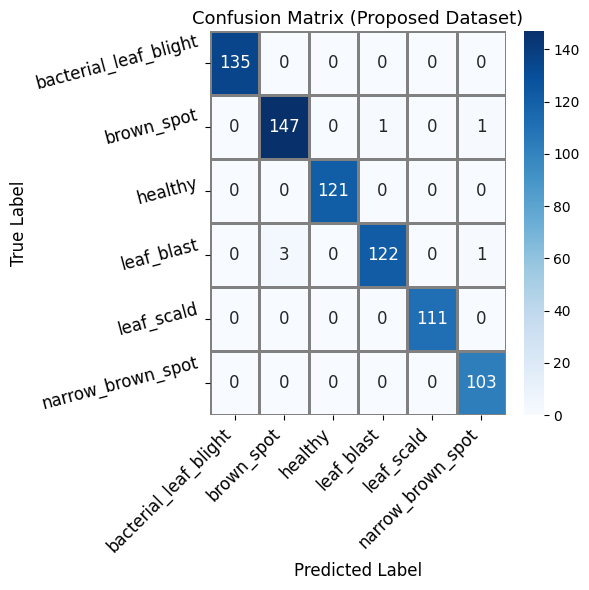

Confusion matrix saved --> Images/confusion_matrix.png


In [11]:
# Cell 28 : Proposed Model -- Confusion Matrix
cm = confusion_matrix(proposed_y_true, proposed_y_pred)
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.8, linecolor='gray', annot_kws={'size': 12}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix (Proposed Dataset)', fontsize=13, pad=5)
ax.tick_params(axis='both', labelsize=12)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(class_names, rotation=15, ha='right', fontsize=12)
plt.tight_layout()
plt.savefig(r'Images\confusion_matrix.png', dpi=300, bbox_inches='tight', format='png')
plt.show()
print('Confusion matrix saved --> Images/confusion_matrix.png')


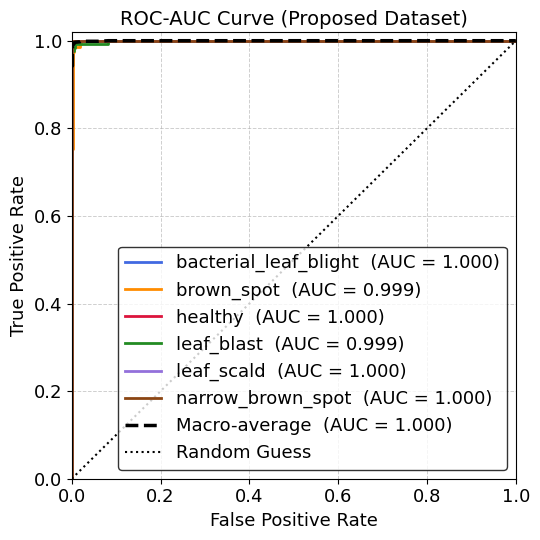

ROC-AUC curve saved --> Images/roc_auc_curve.png
ProposedModel -- GPU memory cleared.


In [12]:
# Cell 29 : Proposed Model -- ROC-AUC Curve
n_classes = NUM_CLASSES
proposed_model.eval()
y_prob_l, y_true_roc = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs  = imgs.to(DEVICE, non_blocking=True)
        out   = proposed_model(imgs)
        probs = torch.softmax(out, dim=1)
        y_prob_l.extend(probs.cpu().numpy())
        y_true_roc.extend(labels.numpy())
y_prob     = np.array(y_prob_l)
y_true_roc = np.array(y_true_roc)
y_true_bin = label_binarize(y_true_roc, classes=range(n_classes))
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])
all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr['macro'] = all_fpr; tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])
colors = ['royalblue','darkorange','crimson','forestgreen','mediumpurple','saddlebrown']
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for i, color in zip(range(n_classes), colors):
    ax.plot(fpr[i], tpr[i], color=color, linewidth=2,
            label=f'{class_names[i]}  (AUC = {roc_auc[i]:.3f})')
ax.plot(fpr['macro'], tpr['macro'], color='black', linewidth=2.5, linestyle='--',
        label=f'Macro-average  (AUC = {roc_auc["macro"]:.3f})')
ax.plot([0, 1], [0, 1], 'k:', linewidth=1.5, label='Random Guess')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title('ROC-AUC Curve (Proposed Dataset)', fontsize=14, pad=5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(loc='lower right', fontsize=13, frameon=True, edgecolor='black')
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
plt.tight_layout()
plt.savefig(r'Images\roc_auc_curve.png', dpi=300, bbox_inches='tight', format='png')
plt.show()
print('ROC-AUC curve saved --> Images/roc_auc_curve.png')
del proposed_model; torch.cuda.empty_cache()
print('ProposedModel -- GPU memory cleared.')
